In [32]:
import sys
!{sys.executable} -m pip install pandas numpy networkx pulp


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import networkx as nx
import pulp
import matplotlib.pyplot as plt

print("--- ENVIRONMENT CHECK ---")
print(f"Pandas version:   {pd.__version__}")
print(f"NumPy version:    {np.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"PuLP version:     {pulp.__version__}")
print("\nSuccess! All required optimization libraries are successfully loaded.")

--- ENVIRONMENT CHECK ---
Pandas version:   3.0.3
NumPy version:    2.4.4
NetworkX version: 3.6.1
PuLP version:     3.3.1

Success! All required optimization libraries are successfully loaded.


In [34]:
# 1. Load the dataset
# Replace 'flight_schedule.csv' with your actual file path
df = pd.read_csv('flight_schedule.csv')

# 2. Convert string timestamps to datetime objects so Python understands time
df['SCHEDULED_DEPARTURE_TIME'] = pd.to_datetime(df['SCHEDULED_DEPARTURE_TIME'])
df['SCHEDULED_ARRIVAL_TIME'] = pd.to_datetime(df['SCHEDULED_ARRIVAL_TIME'])

# 3. Sort chronologically by departure time
# This is critical to ensure our graph is a Directed Acyclic Graph (DAG)
df = df.sort_values(by='SCHEDULED_DEPARTURE_TIME').reset_index(drop=True)

# 4. Calculate the base Flight Time (FT) for each leg in minutes
df['FLIGHT_TIME_MINS'] = (df['SCHEDULED_ARRIVAL_TIME'] - df['SCHEDULED_DEPARTURE_TIME']).dt.total_seconds() / 60

# Inspect the first few rows to ensure it looks correct
print("Data pipeline test successful! Here are the first 5 flights:")
print(df[['LEG_ID', 'DEPARTURE_AIRPORT', 'ARRIVAL_AIRPORT', 'SCHEDULED_DEPARTURE_TIME', 'FLIGHT_TIME_MINS']].head())

Data pipeline test successful! Here are the first 5 flights:
       LEG_ID DEPARTURE_AIRPORT ARRIVAL_AIRPORT SCHEDULED_DEPARTURE_TIME  \
0  3504619488               RAK             DUS      2025-04-27 02:10:00   
1  3504618802               TUN             CGN      2025-04-27 02:10:00   
2  3504619328               EVN             BER      2025-04-27 02:15:00   
3  3504619194               HAJ             PMI      2025-04-27 03:15:00   
4  3504619177               NUE             PMI      2025-04-27 03:40:00   

   FLIGHT_TIME_MINS  
0             235.0  
1             150.0  
2             265.0  
3             150.0  
4             130.0  


In [35]:
def load_and_preprocess_flights(file_path):
    """
    Loads flight schedules, converts timestamps to absolute minutes, 
    and sorts the dataset chronologically.
    """
    # 1. Load the csv file
    df = pd.read_csv(file_path)
    
    # 2. Parse string objects into pandas datetime objects
    df['SCHEDULED_DEPARTURE_TIME'] = pd.to_datetime(df['SCHEDULED_DEPARTURE_TIME'])
    df['SCHEDULED_ARRIVAL_TIME'] = pd.to_datetime(df['SCHEDULED_ARRIVAL_TIME'])
    
    # 3. Sort chronologically by departure time
    # This guarantees that our network flows forward in time (DAG)
    df = df.sort_values(by='SCHEDULED_DEPARTURE_TIME').reset_index(drop=True)
    
    # 4. Establish a global timeline baseline reference point (Day 1 at 00:00)
    baseline_date = df['SCHEDULED_DEPARTURE_TIME'].min().normalize()
    
    # 5. Map timestamps to absolute minutes from baseline
    df['DEP_MINUTES'] = (df['SCHEDULED_DEPARTURE_TIME'] - baseline_date).dt.total_seconds() / 60
    df['ARR_MINUTES'] = (df['SCHEDULED_ARRIVAL_TIME'] - baseline_date).dt.total_seconds() / 60
    
    # 6. Pre-calculate block flight time duration per leg
    df['FLIGHT_DURATION_MINS'] = df['ARR_MINUTES'] - df['DEP_MINUTES']
    
    return df, baseline_date

# Define operational parameters in minutes
MCT = 45          # Minimum Connection Time: 45 minutes
MIN_REST = 720    # Minimum Rest Period between duties: 12 hours (12 * 60)
CHECK_IN = 60     # Duty begins 60 minutes before first departure
CHECK_OUT = 30    # Duty ends 30 minutes after last arrival

print("Data processing functions defined successfully!")

Data processing functions defined successfully!


In [36]:
flights_df, timeline_start = load_and_preprocess_flights('flight_schedule.csv')
print(flights_df[['LEG_ID', 'DEPARTURE_AIRPORT', 'DEP_MINUTES', 'ARR_MINUTES', 'FLIGHT_DURATION_MINS']].head())

       LEG_ID DEPARTURE_AIRPORT  DEP_MINUTES  ARR_MINUTES  \
0  3504619488               RAK        130.0        365.0   
1  3504618802               TUN        130.0        280.0   
2  3504619328               EVN        135.0        400.0   
3  3504619194               HAJ        195.0        345.0   
4  3504619177               NUE        220.0        350.0   

   FLIGHT_DURATION_MINS  
0                 235.0  
1                 150.0  
2                 265.0  
3                 150.0  
4                 130.0  


In [37]:
flights_df.head()

,LEG_ID,DEPARTURE_AIRPORT,ARRIVAL_AIRPORT,SCHEDULED_DEPARTURE_TIME,SCHEDULED_ARRIVAL_TIME,AIRCRAFT_TYPE,DEP_MINUTES,ARR_MINUTES,FLIGHT_DURATION_MINS
0,3504619488,RAK,DUS,2025-04-27 02:10:00,2025-04-27 06:05:00,320,130.0,365.0,235.0
1,3504618802,TUN,CGN,2025-04-27 02:10:00,2025-04-27 04:40:00,737,130.0,280.0,150.0
2,3504619328,EVN,BER,2025-04-27 02:15:00,2025-04-27 06:40:00,320,135.0,400.0,265.0
3,3504619194,HAJ,PMI,2025-04-27 03:15:00,2025-04-27 05:45:00,320,195.0,345.0,150.0
4,3504619177,NUE,PMI,2025-04-27 03:40:00,2025-04-27 05:50:00,320,220.0,350.0,130.0


In [38]:

# 1. Convert the scheduled departure string into a true datetime object
flights_df['SCHEDULED_DEPARTURE_TIME'] = pd.to_datetime(flights_df['SCHEDULED_DEPARTURE_TIME'])

# 2. Extract just the date part (as a datetime object) for clean type-safe filtering
# Note: Using .dt.normalize() keeps it as a datetime type instead of casting to a date object,
# which allows direct, error-free comparisons with date strings!
flights_df['FLIGHT_DATE'] = flights_df['SCHEDULED_DEPARTURE_TIME'].dt.normalize()

# 3. Define the first week of the schedule (Match the year to your data, e.g., 2025 or 2026)
start_date = '2025-04-27'
end_date = '2025-05-03'

# 4. Slice the DataFrame cleanly
weekly_flights = flights_df[(flights_df['FLIGHT_DATE'] >= start_date) & 
                            (flights_df['FLIGHT_DATE'] <= end_date)].copy()

print(f"--- WEEK 1 SLICE COMPLETE ---")
print(f"Total flights found for Week 1: {len(weekly_flights)}")

--- WEEK 1 SLICE COMPLETE ---
Total flights found for Week 1: 3321


In [39]:

# Load your ground transport CSV file
gt_df = pd.read_csv('ground_transportation_times.csv')

# Convert to a fast lookup map: (Origin, Destination) -> duration_in_minutes
# Notice the '* 60' to convert decimal hours (e.g., 2.75) into minutes (165.0)
ground_transit_map = {
    (row['Dep Ap'].strip(), row['Arr Ap'].strip()): row['avg_duration'] * 60
    for _, row in gt_df.iterrows()
}

In [40]:
df_test = pd.read_csv('fdt_limits.csv')
print("--- CSV COLUMNS ---")
print(df_test.columns.tolist())
print("\n--- FIRST 2 ROWS ---")
print(df_test.head(2))

--- CSV COLUMNS ---
['flight_duty_time_start_time', 'flight_duty_time_end_time', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

--- FIRST 2 ROWS ---
  flight_duty_time_start_time flight_duty_time_end_time     1     2     3  \
0                    00:00:00                  04:59:00  11.0  11.0  10.5   
1                    05:00:00                  05:14:00  12.0  12.0  11.5   

      4     5     6    7    8    9   10  
0  10.0   9.5   9.0  9.0  9.0  9.0  9.0  
1  11.0  10.5  10.0  9.5  9.0  9.0  9.0  


In [41]:
def load_easa_limits(csv_path='fdt_limits.csv'):
    """
    Parses fdt_limits.csv using its exact structure:
    Rows are time windows, columns '1' through '10' are sectors containing limit hours.
    """
    df = pd.read_csv(csv_path)
    parsed_limits = []
    
    # Identify the sector columns dynamically (columns that are purely digits)
    sector_columns = [col for col in df.columns if col.isdigit()]
    
    for _, row in df.iterrows():
        # 1. Extract and convert start/end clock times to decimal hours
        start_str = str(row['flight_duty_time_start_time']).strip()
        end_str = str(row['flight_duty_time_end_time']).strip()
        
        start_h = pd.to_timedelta(start_str).total_seconds() / 3600.0
        end_h = pd.to_timedelta(end_str).total_seconds() / 3600.0
        
        # 2. Map each sector column to its minute value (hours * 60)
        sector_map = {}
        for col in sector_columns:
            num_sectors = int(col)
            # Convert float hours from CSV (e.g., 11.5) into total minutes (e.g., 690)
            max_fdt_minutes = int(float(row[col]) * 60)
            sector_map[num_sectors] = max_fdt_minutes
            
        parsed_limits.append(((start_h, end_h), sector_map))
        
    print(f"Successfully mapped {len(parsed_limits)} EASA time windows directly from fdt_limits.csv!")
    return parsed_limits

# Initialize the EASA rule parser globally using your file
EASA_FDT_LIMITS = load_easa_limits('fdt_limits.csv')

Successfully mapped 14 EASA time windows directly from fdt_limits.csv!


In [42]:
def get_max_fdt(check_in_minutes):
    """
    Looks up the dynamic EASA FDT limit based on the absolute minute of check-in.
    """
    minute_of_day = check_in_minutes % 1440
    hour_of_day = minute_of_day / 60.0
    
    for (start_h, end_h), sector_limits in EASA_FDT_LIMITS:
        # Handle night/dawn wrap-around windows if they cross midnight (e.g., 22:00 to 04:00)
        if start_h > end_h: 
            if hour_of_day >= start_h or hour_of_day <= end_h:
                return sector_limits
        else:
            if start_h <= hour_of_day <= end_h:
                return sector_limits
                
    # Safe default fallback matrix if no window catches it
    return {1: 720, 2: 720, 3: 690, 4: 660, 5: 630, 6: 600}

In [43]:
def generate_feasible_duties_with_transit(flights_df, ground_map, MCT=45):
    """
    Generates legal single-day duties accounting for ground transportation.
    Unifies the structural path search with the complete financial costing model,
    capturing flight hours, idle time inefficiencies, hotels, and transit penalties.
    
    CRITICAL FIXES:
    1. Changed chronological 'break' to 'continue' to preserve long-haul outstation options.
    2. Added an Emergency Recovery Overlay to capture isolated long-haul flights as 1-sector lines.
    """
    feasible_duties = []
    num_flights = len(flights_df)
    flights = flights_df.to_dict(orient='records')
    
    # 1. Fast lookups for routing and flight durations
    flight_routing_map = {
        row['LEG_ID']: (row['DEPARTURE_AIRPORT'], row['ARRIVAL_AIRPORT'])
        for _, row in flights_df.iterrows()
    }
    flight_durations = {
        row['LEG_ID']: row['FLIGHT_DURATION_MINS'] 
        for _, row in flights_df.iterrows()
    }
    
    def dfs_extend_duty(current_path, last_idx):
        first_flight = current_path[0]
        last_flight = current_path[-1]
        
        check_in = first_flight['DEP_MINUTES'] - 70   
        check_out = last_flight['ARR_MINUTES'] + 30   
        fdt = last_flight['ARR_MINUTES'] - check_in   
        num_sectors = len(current_path)
        
        # Pull the EASA max limits based on check-in hour
        sector_limits = get_max_fdt(check_in)
        lookup_sector = num_sectors if num_sectors in sector_limits else max(sector_limits.keys())
        max_allowed_fdt = sector_limits.get(lookup_sector, 600) 
        
        if fdt > max_allowed_fdt:
            return 
            
        has_valid_extensions = False
        
        if num_sectors < 5:  
            for next_idx in range(last_idx + 1, num_flights):
                next_flight = flights[next_idx]
                
                time_gap = next_flight['DEP_MINUTES'] - last_flight['ARR_MINUTES']
                
                # FIX 1: If time gap is negative or too large, skip THIS flight, but keep looping!
                # Do not hard-break out of the loop completely.
                if time_gap > 240 or time_gap < 0:
                    continue
                
                arr_ap = last_flight['ARRIVAL_AIRPORT']
                dep_ap = next_flight['DEPARTURE_AIRPORT']
                
                # Scenario A: Standard Connection
                if arr_ap == dep_ap:
                    if MCT <= time_gap <= 240: 
                        has_valid_extensions = True
                        dfs_extend_duty(current_path + [next_flight], next_idx)
                        
                # Scenario B: Ground Surface Connection
                elif (arr_ap, dep_ap) in ground_map:
                    transit_time = ground_map[(arr_ap, dep_ap)]
                    required_window = transit_time + MCT
                    if required_window <= time_gap <= 240:
                        has_valid_extensions = True
                        dfs_extend_duty(current_path + [next_flight], next_idx)

        # --- BALANCED AGGREGATION & PRUNING FILTER ---
        is_at_base_hub = last_flight['ARRIVAL_AIRPORT'] in ['DUS', 'CGN', 'HAM']
        
        if not has_valid_extensions or is_at_base_hub:
            leg_ids = [f['LEG_ID'] for f in current_path]
            
            # --- 2. ADVANCED FINANCIAL ENGINE ---
            total_flight_time = sum(flight_durations[leg_id] for leg_id in leg_ids)
            total_duty_time = check_out - check_in
            
            flying_cost = total_flight_time * 1.00
            inefficiency_cost = (total_duty_time - total_flight_time) * 0.50
            
            # Outstation Hotel Cost Check
            layover_cost = 150.0 if first_flight['DEPARTURE_AIRPORT'] != last_flight['ARRIVAL_AIRPORT'] else 0.0
            
            # Ground Transportation Cost Check
            ground_transit_cost = 0.0
            total_ground_minutes = 0.0  
            itinerary_airports = [flight_routing_map[leg_ids[0]][0]]
            
            for k in range(len(current_path)):
                leg_id = leg_ids[k]
                dep_ap, arr_ap = flight_routing_map[leg_id]
                
                if k > 0 and itinerary_airports[-1] != dep_ap:
                    prev_arr = itinerary_airports[-1]
                    if (prev_arr, dep_ap) in ground_map:
                        transit_minutes = ground_map[(prev_arr, dep_ap)]
                        total_ground_minutes += transit_minutes
                        ground_transit_cost += 50.0 + (transit_minutes * 0.50)
                        itinerary_airports.append(f"({prev_arr}🚌{dep_ap})")
                
                itinerary_airports.append(arr_ap)
            
            duty_itinerary = " ➔ ".join(itinerary_airports)
            final_calculated_cost = flying_cost + inefficiency_cost + layover_cost + ground_transit_cost
            
            duty_info = {
                'flight_legs': leg_ids,
                'itinerary': duty_itinerary,  
                'origin_airport': first_flight['DEPARTURE_AIRPORT'],
                'destination_airport': last_flight['ARRIVAL_AIRPORT'],
                'start_time': check_in,
                'end_time': check_out,
                'fdt_duration': fdt,
                'sectors': num_sectors,
                'ground_transit_mins': round(total_ground_minutes, 1), 
                'duty_cost': round(final_calculated_cost, 2)
            }
            feasible_duties.append(duty_info)

    # Execute graph search for all core flights
    for i in range(num_flights):
        dfs_extend_duty([flights[i]], i)
        
    # --- FIX 2: EMERGENCY RECOVERY OVERLAY ---
    # Find any long-haul legs that found zero valid duties due to strict morning limits
    legs_with_duties = set()
    for duty in feasible_duties:
        for leg in duty['flight_legs']:
            legs_with_duties.add(leg)
            
    print(f"Heuristic generated {len(feasible_duties)} base duties. Checking for gaps...")
    
    recovered_count = 0
    for f in flights:
        if f['LEG_ID'] not in legs_with_duties:
            check_in = f['DEP_MINUTES'] - 70
            check_out = f['ARR_MINUTES'] + 30
            fdt = f['ARR_MINUTES'] - check_in
            
            flying_cost = f['FLIGHT_DURATION_MINS'] * 1.00
            inefficiency_cost = (check_out - check_in - f['FLIGHT_DURATION_MINS']) * 0.50
            layover_cost = 150.0  # Safe outstation hotel layover assignment
            
            recovery_duty = {
                'flight_legs': [f['LEG_ID']],
                'itinerary': f"{f['DEPARTURE_AIRPORT']} ➔ {f['ARRIVAL_AIRPORT']} (Layover Line)",
                'origin_airport': f['DEPARTURE_AIRPORT'],
                'destination_airport': f['ARRIVAL_AIRPORT'],
                'start_time': check_in,
                'end_time': check_out,
                'fdt_duration': fdt,
                'sectors': 1,
                'ground_transit_mins': 0.0,
                'duty_cost': round(flying_cost + inefficiency_cost + layover_cost, 2)
            }
            feasible_duties.append(recovery_duty)
            legs_with_duties.add(f['LEG_ID'])
            recovered_count += 1

    if recovered_count > 0:
        print(f"🛡️ Safety Net Triggered: Successfully recovered {recovered_count} long-haul gaps into layover duties.")
        
    return pd.DataFrame(feasible_duties)

In [44]:
# 1. Generate the legal single-day duties using your processed flights dataframe
weekly_duties = generate_feasible_duties_with_transit(weekly_flights, ground_transit_map, MCT=45)

# 2. Print the verification metrics
print("\n--- LAYER 1: DUTY GENERATION COMPLETE ---")
print(f"Total valid daily duties discovered: {len(weekly_duties)}")

if len(weekly_duties) > 0:
    print("\nSample Generated Duties Layout:")
    print(weekly_duties[['flight_legs', 'origin_airport', 'destination_airport', 'fdt_duration', 'sectors']].head())

Heuristic generated 32816 base duties. Checking for gaps...
🛡️ Safety Net Triggered: Successfully recovered 53 long-haul gaps into layover duties.

--- LAYER 1: DUTY GENERATION COMPLETE ---
Total valid daily duties discovered: 32869

Sample Generated Duties Layout:
                flight_legs origin_airport destination_airport  fdt_duration  \
0  [3504619488, 3504619464]            RAK                 OTP         500.0   
1  [3504619488, 3504619358]            RAK                 NCE         470.0   
2  [3504619488, 3504619366]            RAK                 LHR         445.0   
3  [3504619488, 3504619476]            RAK                 FLR         475.0   
4  [3504619488, 3504619450]            RAK                 KRK         480.0   

   sectors  
0        2  
1        2  
2        2  
3        2  
4        2  


In [45]:
gt_duties = weekly_duties[weekly_duties['ground_transit_mins'] > 0]
print(gt_duties[['flight_legs', 'origin_airport', 'destination_airport', 'ground_transit_mins', 'duty_cost']].head())

                 flight_legs origin_airport destination_airport  \
8   [3504618802, 3504619448]            TUN                 MLA   
9   [3504618802, 3504619464]            TUN                 OTP   
10  [3504618802, 3504619358]            TUN                 NCE   
11  [3504618802, 3504619366]            TUN                 LHR   
12  [3504618802, 3504619476]            TUN                 FLR   

    ground_transit_mins  duty_cost  
8                  79.8      672.4  
9                  79.8      654.9  
10                 79.8      619.9  
11                 79.8      594.9  
12                 79.8      619.9  


In [46]:
weekly_duties.to_csv('single_day_duties.csv', index=False, encoding='utf-8-sig')

In [47]:
weekly_duties.head()

,flight_legs,itinerary,origin_airport,destination_airport,start_time,end_time,fdt_duration,sectors,ground_transit_mins,duty_cost
0,"[3504619488, 3504619464]",RAK ➔ DUS ➔ OTP,RAK,OTP,60.0,590.0,500.0,2,0.0,607.5
1,"[3504619488, 3504619358]",RAK ➔ DUS ➔ NCE,RAK,NCE,60.0,560.0,470.0,2,0.0,572.5
2,"[3504619488, 3504619366]",RAK ➔ DUS ➔ LHR,RAK,LHR,60.0,535.0,445.0,2,0.0,547.5
3,"[3504619488, 3504619476]",RAK ➔ DUS ➔ FLR,RAK,FLR,60.0,565.0,475.0,2,0.0,572.5
4,"[3504619488, 3504619450]",RAK ➔ DUS ➔ KRK,RAK,KRK,60.0,570.0,480.0,2,0.0,575.0


In [48]:
def build_pairing_graph_fast(duties_df, MIN_REST=720, MAX_LAYOVER=1440, max_nodes=100000, max_successors_per_node=10):
    """
    High-speed vectorized pairing graph builder with structural pruning.
    Caps max successors per node to prevent combinatorial explosion in multi-day tracking.
    """
    # Safe downsampling check to guard your laptop's RAM
    if len(duties_df) > max_nodes:
        print(f"⚠️ Duty library size ({len(duties_df)}) is large for standard RAM.")
        print(f"Sampling the top {max_nodes} structurally diverse duties...")
        working_df = duties_df.sort_values(by=['duty_cost', 'start_time']).head(max_nodes).copy()
    else:
        working_df = duties_df.copy()

    G = nx.DiGraph()
    
    print("Vectorizing nodes into memory network...")
    for idx, row in working_df.iterrows():
        G.add_node(idx,
                   origin=row['origin_airport'],
                   destination=row['destination_airport'],
                   start=row['start_time'],
                   end=row['end_time'],
                   cost=row['duty_cost'],
                   legs=row['flight_legs'])
        
    print("Executing matrix cross-join connection tracking with local pruning...")
    
    node_ids = working_df.index.to_numpy()
    origins = working_df['origin_airport'].to_numpy()
    destinations = working_df['destination_airport'].to_numpy()
    starts = working_df['start_time'].to_numpy()
    ends = working_df['end_time'].to_numpy()
    
    edge_list = []
    unique_airports = working_df['origin_airport'].unique()
    
    for airport in unique_airports:
        idx_A = np.where(destinations == airport)[0] # Duties ending here
        idx_B = np.where(origins == airport)[0]      # Duties starting here
        
        if len(idx_A) == 0 or len(idx_B) == 0:
            continue
            
        # Broadcast times to find layovers (Shape: len(idx_A) x len(idx_B))
        layovers = starts[idx_B][None, :] - ends[idx_A][:, None]
        
        # Apply legal rest filters (Notice MAX_LAYOVER default is now 1440 mins / 24 hours!)
        valid_pairs = (layovers >= MIN_REST) & (layovers <= MAX_LAYOVER)
        row_indices, col_indices = np.where(valid_pairs)
        
        # Build a temporary mapping to prune connections locally per incoming node
        local_connections = {r: [] for r in np.unique(row_indices)}
        for r, c in zip(row_indices, col_indices):
            local_connections[r].append((c, layovers[r, c]))
            
        # CRITICAL OPTIMIZATION STEP: Prune the branching factor!
        for r, options in local_connections.items():
            global_idx_A = node_ids[idx_A[r]]
            
            # Sort options by layover time (shortest rest first = highly efficient)
            sorted_options = sorted(options, key=lambda x: x[1])
            
            # Keep only the top N best connections
            for c, layover_time in sorted_options[:max_successors_per_node]:
                global_idx_B = node_ids[idx_B[c]]
                edge_list.append((global_idx_A, global_idx_B, {'layover_time': layover_time}))

    print(f"Writing {len(edge_list)} pruned edges into the network layout...")
    G.add_edges_from(edge_list)
    
    print(f"Success! Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    return G

In [49]:
# 1. Rebuild the pairing network graph using our pruned logic
weekly_G = build_pairing_graph_fast(
    weekly_duties, 
    MIN_REST=720, 
    MAX_LAYOVER=1440,       # Capped at 24 hours max hotel stay
    max_nodes=100000, 
    max_successors_per_node=10  # Only links to the 10 best connecting flights
)



Vectorizing nodes into memory network...
Executing matrix cross-join connection tracking with local pruning...
Writing 258669 pruned edges into the network layout...
Success! Nodes: 32869 | Edges: 258669


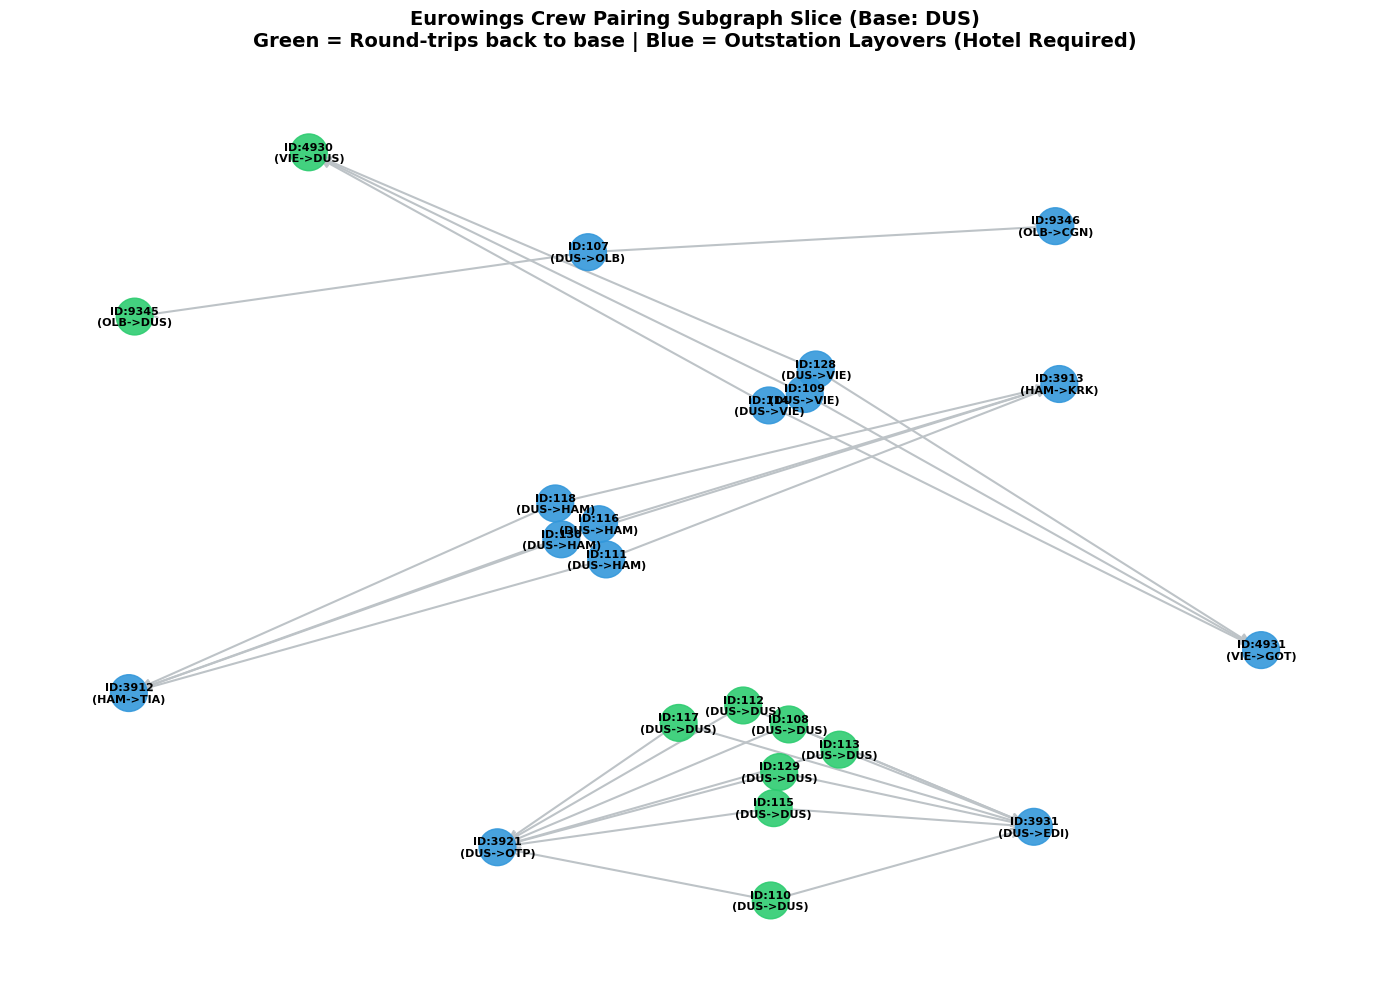

In [50]:
def visualize_sample_subgraph(G, target_base='DUS', max_nodes_to_show=10):
    """
    Extracts and plots a visually clean slice of the pairing graph 
    originating from a specific home base.
    """
    # 1. Find nodes that start at our target base airport
    sample_nodes = [n for n, d in G.nodes(data=True) if d['origin'] == target_base][:max_nodes_to_show]
    
    # 2. Add some of their immediate legal connections (successors) to show transitions
    extended_nodes = list(sample_nodes)
    for n in sample_nodes:
        successors = list(G.successors(n))
        extended_nodes.extend(successors[:2]) # Grab up to 2 legal overnights per duty
        
    # Remove duplicates
    subgraph_nodes = list(set(extended_nodes))
    sub_G = G.subgraph(subgraph_nodes)
    
    # 3. Define the visual layout
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(sub_G, k=0.5, seed=42) # Spreads out the nodes nicely
    
    # 4. Color-code nodes by their destination to see where crews are flying to sleep
    node_colors = []
    for n in sub_G.nodes():
        dest = G.nodes[n]['destination']
        if dest == target_base:
            node_colors.append('#2ecc71') # Green for round-trips returning home
        else:
            node_colors.append('#3498db') # Blue for duties ending at an outstation layover
            
    # 5. Draw the network elements
    nx.draw_networkx_nodes(sub_G, pos, node_size=700, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(sub_G, pos, arrowstyle='->', arrowsize=15, edge_color='#bdc3c7', width=1.5)
    
    # Label nodes with their ID and Route string
    labels = {n: f"ID:{n}\n({G.nodes[n]['origin']}->{G.nodes[n]['destination']})" for n in sub_G.nodes()}
    nx.draw_networkx_labels(sub_G, pos, labels=labels, font_size=8, font_family='sans-serif', font_weight='bold')
    
    plt.title(f"Eurowings Crew Pairing Subgraph Slice (Base: {target_base})\n"
              f"Green = Round-trips back to base | Blue = Outstation Layovers (Hotel Required)", 
              fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run the visualizer on your compiled graph!
visualize_sample_subgraph(weekly_G, target_base='DUS', max_nodes_to_show=15)

In [51]:

def extract_pairings_ultra_fast(G, flights_df, max_days=3):
    """
    Ultra-fast DFS extractor with a robust, foolproof flying hours calculation.
    Cross-references flight leg IDs directly against the source flights data.
    """
    pairings = []
    
    print("Mapping network elements...")
    node_data = {n: d for n, d in G.nodes(data=True)}
    successors = {n: list(G.successors(n)) for n in G.nodes()}
    
    # Create a blazing-fast dictionary lookup for every single flight leg's duration
    # Leg ID -> Duration in Hours
    flight_durations = {
        row['LEG_ID']: (row['ARR_MINUTES'] - row['DEP_MINUTES']) / 60.0 
        for _, row in flights_df.iterrows()
    }
    
    print("Extracting paths with operational pruning rules...")
    
    # Helper function to look up and sum the exact flying hours for any duty node
    def get_pairing_flying_hours(node_list):
        total_hours = 0.0
        for node in node_list:
            # Gather the leg IDs inside this specific duty
            legs = node_data[node]['legs']
            # Sum up their exact durations from our lookup map
            total_hours += sum(flight_durations.get(leg, 0.0) for leg in legs)
        return round(total_hours, 2)

    for node_1, data_1 in node_data.items():
        base = data_1['origin']
        outstation_1 = data_1['destination']
        
        # --- DAY 1 ROUND-TRIP (Instant) ---
        if outstation_1 == base:
            pairings.append({
                'duty_chain': [node_1],
                'home_base': base,
                'total_cost': data_1['cost'],
                'num_days': 1,
                'flying_hours': get_pairing_flying_hours([node_1]),
                'covered_legs': data_1['legs']
            })
            continue 
            
        # --- DAY 2 PATHS ---
        if max_days < 2:
            continue
            
        for node_2 in successors[node_1]:
            data_2 = node_data[node_2]
            outstation_2 = data_2['destination']
            
            # Day 2: Returns Home
            if outstation_2 == base:
                pairings.append({
                    'duty_chain': [node_1, node_2],
                    'home_base': base,
                    'total_cost': data_1['cost'] + data_2['cost'],
                    'num_days': 2,
                    'flying_hours': get_pairing_flying_hours([node_1, node_2]),
                    'covered_legs': data_1['legs'] + data_2['legs']
                })
                
            # --- DAY 3 PATHS ---
            if max_days < 3:
                continue
                
            if data_2['origin'] == outstation_1 and outstation_2 == outstation_1:
                continue
                
            for node_3 in successors[node_2]:
                data_3 = node_data[node_3]
                
                # Day 3: Must return home to base
                if data_3['destination'] == base:
                    pairings.append({
                        'duty_chain': [node_1, node_2, node_3],
                        'home_base': base,
                        'total_cost': data_1['cost'] + data_2['cost'] + data_3['cost'],
                        'num_days': 3,
                        'flying_hours': get_pairing_flying_hours([node_1, node_2, node_3]),
                        'covered_legs': data_1['legs'] + data_2['legs'] + data_3['legs']
                    })
                    
    final_df = pd.DataFrame(pairings)
    print(f" Execution successful! Compiled {len(final_df)} high-quality legal pairings.")
    return final_df

In [52]:
# Run the ultra-pruned version
weekly_pairings = extract_pairings_ultra_fast(weekly_G, flights_df,max_days=3)

# View the pairing layout
print(weekly_pairings[['duty_chain', 'home_base', 'num_days', 'total_cost', 'flying_hours']].head())

Mapping network elements...
Extracting paths with operational pruning rules...
 Execution successful! Compiled 73821 high-quality legal pairings.
          duty_chain home_base  num_days  total_cost  flying_hours
0  [33, 6209, 13892]       CGN         3      2130.0         20.67
1  [33, 6209, 13897]       CGN         3      2047.5         19.17
2  [33, 6212, 12556]       CGN         3      1962.5         19.33
3         [33, 6213]       CGN         2      1372.5         13.33
4  [33, 6213, 12729]       CGN         3      1800.0         19.25


In [53]:
weekly_pairings['duty_chain'] = weekly_pairings['duty_chain'].apply(lambda chain: [int(node) for node in chain])
#weekly_pairings.to_csv('weekly_pairings.csv', index=False)

Optimization part

In [54]:
import gurobipy as gp
from gurobipy import GRB

In [55]:
import pandas as pd
import numpy as np
from collections import defaultdict

def run_final_leg_coverage_engine(daily_duties_path, flightsdf, ground_map, max_iterations=15):
    print("=== INITIALIZING INSTANT SEEDED COVERAGE ENGINE ===")
    
    # 1. LOAD AND PREPARE DATA
    duties_df = pd.read_csv(daily_duties_path)
    duties = duties_df.to_dict(orient='records')
    
    for d in duties:
        if isinstance(d['flight_legs'], str):
            d['flight_legs'] = eval(d['flight_legs'])
            
    unique_legs = flightsdf['LEG_ID'].unique().tolist()
    unique_bases = ['CGN', 'DUS', 'HAM']
    
    duties_by_day_and_origin = defaultdict(list)
    for d in duties:
        day = int(d['start_time'] // 1440) + 1 
        d['assigned_day'] = day
        duties_by_day_and_origin[(day, d['origin_airport'])].append(d)

    # 2. OPTIMIZED SEEDING (MINIMAL BALANCED COVERAGE)
    rmp_columns = []
    covered_in_seeding = set()
    
    print("⚡ Filtering minimal dataset to seed baseline columns...")
    # Sort duties by cost so we pick the cheapest ones to seed first
    sorted_duties = sorted(duties, key=lambda x: x['duty_cost'])
    
    for idx, d in enumerate(sorted_duties):
        # Only inject the duty if it covers at least one flight leg not yet seeded
        if any(leg_id not in covered_in_seeding for leg_id in d['flight_legs']):
            rmp_columns.append({
                'pairing_id': f"duty_seed_{idx}",
                'covered_legs': list(d['flight_legs']),
                'total_cost': float(d['duty_cost']),
                'duty_itineraries': [d['itinerary']]
            })
            for leg_id in d['flight_legs']:
                covered_in_seeding.add(leg_id)

    # Safety stubs for any absolute logical gaps
    for leg_id in unique_legs:
        if leg_id not in covered_in_seeding:
            rmp_columns.append({
                'pairing_id': f"artif_{leg_id}",
                'covered_legs': [leg_id],
                'total_cost': 500000.0, 
                'duty_itineraries': ['Emergency Standby Stub']
            })

    env = gp.Env(empty=True)
    env.setParam('OutputFlag', 0)
    env.start()
    
    # 3. HIGH-SPEED COLUMN GENERATION LOOP
    for iteration in range(1, max_iterations + 1):
        model = gp.Model("RMP_Continuous", env=env)
        model.setParam('Method', 1) # Dual Simplex
        
        # Fast bulk variable mapping
        x = model.addVars([col['pairing_id'] for col in rmp_columns], lb=0.0, ub=1.0, 
                          obj=[col['total_cost'] for col in rmp_columns], vtype=GRB.CONTINUOUS)
        model.modelSense = GRB.MINIMIZE
        
        leg_to_col_map = defaultdict(list)
        for col in rmp_columns:
            for leg in col['covered_legs']:
                leg_to_col_map[leg].append(col['pairing_id'])
                
        constraints = {}
        for leg_id in unique_legs:
            legs_in_map = leg_to_col_map.get(leg_id, [])
            if legs_in_map:
                expr = gp.quicksum(x[pid] for pid in legs_in_map)
                constraints[leg_id] = model.addConstr(expr >= 1.0, name=f"Cover_{leg_id}")
            
        model.optimize()
        
        if model.status != GRB.OPTIMAL:
            print("⚠️ RMP optimization stalled.")
            break
            
        current_obj = model.objVal
        dual_variables = {leg_id: constraints[leg_id].Pi if leg_id in constraints else 0.0 for leg_id in unique_legs}
        
        for d in duties:
            sum_duals = sum(dual_variables.get(leg, 0.0) for leg in d['flight_legs'])
            d['modified_cost'] = d['duty_cost'] - sum_duals

        # Pricing Engine (DFS)
        collected_pairings = []
        
        def dfs_price(current_duty, home_base, current_path_duties, current_rc, current_cost, current_legs, current_itineraries):
            if len(collected_pairings) >= 25: 
                return
            if current_duty['destination_airport'] == home_base:
                if current_rc < -1.0: # Only grab clean, highly profitable paths
                    collected_pairings.append({
                        'covered_legs': list(current_legs),
                        'total_cost': current_cost,
                        'duty_itineraries': list(current_itineraries)
                    })
                    return 
            if len(current_path_duties) >= 4: 
                return
                
            next_day = current_duty['assigned_day'] + 1
            current_ap = current_duty['destination_airport']
            
            potential_next = list(duties_by_day_and_origin[(next_day, current_ap)])
            for target_ap in unique_bases:
                if (current_ap, target_ap) in ground_map:
                    potential_next.extend(duties_by_day_and_origin[(next_day, target_ap)])
            
            if not potential_next and current_ap not in unique_bases:
                for hub in unique_bases:
                    virtual_deadhead_duty = {
                        'assigned_day': next_day,
                        'origin_airport': current_ap,
                        'destination_airport': hub,
                        'start_time': current_duty['end_time'] + 720, 
                        'end_time': current_duty['end_time'] + 720 + 180,
                        'duty_cost': 400.0,
                        'modified_cost': 400.0,
                        'flight_legs': [],
                        'itinerary': f"({current_ap}✈️DH✈️{hub})"
                    }
                    potential_next.append(virtual_deadhead_duty)
            
            for next_duty in potential_next:
                if next_duty['start_time'] - current_duty['end_time'] < 720: 
                    continue
                new_rc = current_rc + next_duty['modified_cost']
                if new_rc > 5000: 
                    continue
                dfs_price(next_duty, home_base, current_path_duties + [next_duty], new_rc,
                          current_cost + next_duty['duty_cost'], current_legs + list(next_duty['flight_legs']),
                          current_itineraries + [next_duty['itinerary']])

        new_columns_this_iter = []
        for base in unique_bases:
            collected_pairings = [] 
            for day in [1, 2, 3, 4]: 
                if (day, base) in duties_by_day_and_origin:
                    for start_duty in duties_by_day_and_origin[(day, base)]:
                        if start_duty['modified_cost'] > 1000: 
                            continue 
                        dfs_price(start_duty, base, [start_duty], start_duty['modified_cost'], start_duty['duty_cost'],
                                  list(start_duty['flight_legs']), [start_duty['itinerary']])
                        if len(collected_pairings) >= 25:
                            break
            
            for path in collected_pairings:
                pid = f"g_gen_{iteration}_{base}_{np.random.randint(10000, 99999)}"
                new_columns_this_iter.append({
                    'pairing_id': pid,
                    'covered_legs': path['covered_legs'],
                    'total_cost': path['total_cost'],
                    'duty_itineraries': path['duty_itineraries']
                })

        if not new_columns_this_iter:
            print(f"Iteration {iteration:02d} | ✅ CONVERGENCE.")
            break
        else:
            print(f"Iteration {iteration:02d} | Cost: €{current_obj:,.2f} | Added {len(new_columns_this_iter)} pairings.")
            
        rmp_columns.extend(new_columns_this_iter)
        
    # 4. PHASE 2: MIXED-INTEGER LINEAR PROGRAMMING (MILP) SOLVE
    print("\n🚀 Phase 2: Running Final Fast MILP Selection...")
    milp = gp.Model("Final_Integer_RMP", env=env)
    milp.setParam('Presolve', 2)
    milp.setParam('MIPGap', 0.001) # 0.1% optimization gap threshold for fast compilation
    
    x_int = milp.addVars([col['pairing_id'] for col in rmp_columns], vtype=GRB.BINARY, 
                         obj=[col['total_cost'] for col in rmp_columns])
    milp.modelSense = GRB.MINIMIZE
    
    leg_to_final_map = defaultdict(list)
    for col in rmp_columns:
        for leg in col['covered_legs']:
            leg_to_final_map[leg].append(col['pairing_id'])
            
    for leg_id in unique_legs:
        legs_in_map = leg_to_final_map.get(leg_id, [])
        if legs_in_map:
            milp.addConstr(gp.quicksum(x_int[pid] for pid in legs_in_map) >= 1.0)
        
    milp.optimize()
    
    chosen_columns = [col for col in rmp_columns if x_int[col['pairing_id']].X > 0.5]
    return pd.DataFrame(chosen_columns)

In [56]:
weekly_optimized_pairings_df = run_final_leg_coverage_engine(
    daily_duties_path="single_day_duties.csv", 
    flightsdf=weekly_flights, 
    ground_map=ground_transit_map
)

# Save the results
weekly_optimized_pairings_df.to_csv("optimized_weekly_pairings.csv", index=False, encoding='utf-8-sig')
print("🎉 Done! Output generated successfully.")

=== INITIALIZING INSTANT SEEDED COVERAGE ENGINE ===
⚡ Filtering minimal dataset to seed baseline columns...
Iteration 01 | Cost: €891,441.90 | Added 75 pairings.
Iteration 02 | Cost: €890,134.40 | Added 75 pairings.
Iteration 03 | Cost: €889,826.90 | Added 75 pairings.
Iteration 04 | Cost: €889,094.40 | Added 75 pairings.
Iteration 05 | Cost: €888,949.40 | Added 75 pairings.
Iteration 06 | Cost: €888,719.40 | Added 75 pairings.
Iteration 07 | Cost: €888,601.90 | Added 75 pairings.
Iteration 08 | Cost: €888,304.40 | Added 75 pairings.
Iteration 09 | Cost: €888,304.40 | Added 75 pairings.
Iteration 10 | Cost: €888,289.40 | Added 75 pairings.
Iteration 11 | Cost: €888,064.40 | Added 75 pairings.
Iteration 12 | Cost: €887,734.40 | Added 75 pairings.
Iteration 13 | Cost: €887,479.40 | Added 75 pairings.
Iteration 14 | Cost: €887,136.90 | Added 75 pairings.
Iteration 15 | Cost: €886,737.00 | Added 75 pairings.

🚀 Phase 2: Running Final Fast MILP Selection...
🎉 Done! Output generated successf

In [57]:
weekly_flights.head()

,LEG_ID,DEPARTURE_AIRPORT,ARRIVAL_AIRPORT,SCHEDULED_DEPARTURE_TIME,SCHEDULED_ARRIVAL_TIME,AIRCRAFT_TYPE,DEP_MINUTES,ARR_MINUTES,FLIGHT_DURATION_MINS,FLIGHT_DATE
0,3504619488,RAK,DUS,2025-04-27 02:10:00,2025-04-27 06:05:00,320,130.0,365.0,235.0,2025-04-27
1,3504618802,TUN,CGN,2025-04-27 02:10:00,2025-04-27 04:40:00,737,130.0,280.0,150.0,2025-04-27
2,3504619328,EVN,BER,2025-04-27 02:15:00,2025-04-27 06:40:00,320,135.0,400.0,265.0,2025-04-27
3,3504619194,HAJ,PMI,2025-04-27 03:15:00,2025-04-27 05:45:00,320,195.0,345.0,150.0,2025-04-27
4,3504619177,NUE,PMI,2025-04-27 03:40:00,2025-04-27 05:50:00,320,220.0,350.0,130.0,2025-04-27


In [58]:

# Load your duties
df = pd.read_csv("single_day_duties.csv")

# Extract unique arrival airports on Day 1
day1_destinations = set(df[df['start_time'] < 1440]['destination_airport'].unique())

# Extract unique departure airports on Day 2
day2_origins = set(df[(df['start_time'] >= 1440) & (df['start_time'] < 2880)]['origin_airport'].unique())

# Find the missing links
stranded_airports = day1_destinations - day2_origins
print(f"Airports where crews get stuck on Day 1 with no departing flights on Day 2: {stranded_airports}")

Airports where crews get stuck on Day 1 with no departing flights on Day 2: {'DBV', 'PRN', 'FLR', 'HEL', 'DWC', 'SVQ', 'LPA', 'AGA', 'MLA'}


### week flight -> optimal soln by CG

In [59]:
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from collections import defaultdict

def generate_optimal_weekly_roster_scp(flights_df, ground_map, MCT=45, max_iterations=15, 
                                      single_leg_penalty=500.0, start_date='2025-04-27', end_date='2025-05-03', 
                                      max_captains=433,
                                      min_layover_hours=12.0,       
                                      max_layover_hours=36.0,       
                                      layover_cost_per_hour=25.0): 
    """
    Direct Column Generation Pipeline (SET COVERING VERSION):
    Converts raw weekly flight data frames directly into optimal 7-day pairings.
    
    UPDATES INTEGRATED:
    1. Set Covering Relaxations (>= 1.0) implemented in both continuous loop and MILP.
    2. Dynamic Horizon Masking: Evaluates mandatory coverage only within start_date and end_date.
    3. Absolute-Time to Day-1/7 Indexing Repair: Converts timestamps to relative day windows.
    4. Global Crew Capacity Constraint: Strictly bounds total organic pairings to available captains (Max 433).
    5. Customizable Layover Rest Windows & Multi-Day Cost Metrics.
    """
    print("====== STARTING DIRECT WEEKLY CREW SCHEDULING PIPELINE (SCP) ======")
    print(f"Total buffer-extended flights in memory: {len(flights_df)}")
    
    # Convert configuration hours to minutes for operational timestamp tracking
    min_layover_mins = min_layover_hours * 60
    max_layover_mins = max_layover_hours * 60
    
    # Define exact Timestamp Boundaries
    core_start_dt = pd.to_datetime(f"{start_date} 00:00:00")
    core_end_dt = pd.to_datetime(f"{end_date} 23:59:59")
    
    # Extract unique flights that strictly MUST be covered (Core target week)
    core_flights = flights_df[(flights_df['SCHEDULED_DEPARTURE_TIME'] >= core_start_dt) & 
                              (flights_df['SCHEDULED_DEPARTURE_TIME'] <= core_end_dt)]
    unique_legs = core_flights['LEG_ID'].unique().tolist()
    
    print(f"Mandatory flights to cover in core target horizon ({start_date} to {end_date}): {len(unique_legs)}")
    
    # -------------------------------------------------------------
    # STEP 1: LAYER 1 - IN-MEMORY DUTY GENERATION
    # -------------------------------------------------------------
    print("\n[Layer 1] Building valid daily duty blocks across the horizon...")
    duties_df = generate_feasible_duties_with_transit(flights_df, ground_map, MCT=MCT)
    duties = duties_df.to_dict(orient='records')
    print(f"[Layer 1] Success! Compiled {len(duties)} legal single-day operations.")
    
    # -------------------------------------------------------------
    # STEP 2: FIXED RELATIVE MULTI-DAY TIME WINDOW MAP PREPARATION
    # -------------------------------------------------------------
    unique_bases = ['DUS', 'STR', 'HAM', 'CGN', 'BER', 'NUE', 'HAJ']
    duties_by_day_and_origin = defaultdict(list)
    
    # Fix: Dynamically track how many calendar days a layover can span for looking ahead
    max_days_lookahead = int(np.ceil(max_layover_hours / 24.0)) + 1
    
    for d in duties:
        duty_start_dt = pd.to_datetime(d['start_time'], unit='m', origin='unix') 
        
        # Calculate day relative to your horizon window (Day 1 to Day 8+)
        day = (duty_start_dt - core_start_dt).days + 1
        d['assigned_day'] = day
        duties_by_day_and_origin[(day, d['origin_airport'])].append(d)

    # -------------------------------------------------------------
    # STEP 3: OPTIMIZED SEEDING WITH BASE-ONLY RESTRICTIONS FOR STABILITY
    # -------------------------------------------------------------
    print("\n[Layer 2] Initializing Restricted Master Problem (RMP) seed columns...")
    rmp_columns = []
    covered_in_seeding = set()
    sorted_duties = sorted(duties, key=lambda x: x['duty_cost'])
    
    for idx, d in enumerate(sorted_duties):
        # Math Strategy: Restrict structural seed duties to start/end at crew hubs for cleaner initial dual paths
        is_base_to_base = d['origin_airport'] in unique_bases and d['destination_airport'] in unique_bases
        
        if is_base_to_base and any(leg_id in unique_legs and leg_id not in covered_in_seeding for leg_id in d['flight_legs']):
            base_cost = float(d['duty_cost'])
            if len(d['flight_legs']) == 1:
                base_cost += single_leg_penalty
                
            rmp_columns.append({
                'pairing_id': f"duty_seed_{idx}",
                'covered_legs': list(d['flight_legs']),
                'total_cost': base_cost,
                'duty_itineraries': [d['itinerary']]
            })
            for leg_id in d['flight_legs']:
                if leg_id in unique_legs:
                    covered_in_seeding.add(leg_id)

    for leg_id in unique_legs:
        if leg_id not in covered_in_seeding:
            rmp_columns.append({
                'pairing_id': f"artif_{leg_id}",
                'covered_legs': [leg_id],
                'total_cost': 500000.0, 
                'duty_itineraries': ['Emergency Standby Stub']
            })

    env = gp.Env(empty=True)
    env.setParam('OutputFlag', 0)
    env.start()
    
    # -------------------------------------------------------------
    # STEP 4: COLUMN GENERATION CORE ITERATIONS (SET COVERING)
    # -------------------------------------------------------------
    print("\n[Layer 2] Executing continuous column generation matrix loop...")
    for iteration in range(1, max_iterations + 1):
        model = gp.Model("RMP_Continuous", env=env)
        model.setParam('Method', 1)  # Force dual simplex pricing
        
        x = model.addVars([col['pairing_id'] for col in rmp_columns], lb=0.0, ub=1.0, 
                          obj=[col['total_cost'] for col in rmp_columns], vtype=GRB.CONTINUOUS)
        model.modelSense = GRB.MINIMIZE
        
        leg_to_col_map = defaultdict(list)
        for col in rmp_columns:
            for leg in col['covered_legs']:
                if leg in unique_legs: 
                    leg_to_col_map[leg].append(col['pairing_id'])
                
        constraints = {}
        for leg_id in unique_legs:
            legs_in_map = leg_to_col_map.get(leg_id, [])
            if legs_in_map:
                expr = gp.quicksum(x[pid] for pid in legs_in_map)
                # !!! SCP MODIFICATION: Changed equality (== 1.0) to inequality (>= 1.0) !!!
                constraints[leg_id] = model.addConstr(expr >= 1.0, name=f"Cover_{leg_id}")
            
        model.optimize()
        
        if model.status != GRB.OPTIMAL:
            print("⚠️ Mathematical core stalled or infeasible under strict covering continuous relaxation.")
            break
            
        current_obj = model.objVal
        dual_variables = {leg_id: constraints[leg_id].Pi if leg_id in constraints else 0.0 for leg_id in unique_legs}
        
        for d in duties:
            sum_duals = sum(dual_variables.get(leg, 0.0) for leg in d['flight_legs'] if leg in unique_legs)
            d['modified_cost'] = d['duty_cost'] - sum_duals

        # Multi-Day Pricing Search Subproblem (DFS)
        collected_pairings = []
        
        def dfs_price(current_duty, home_base, current_path_duties, current_rc, current_cost, current_legs, current_itineraries):
            if len(collected_pairings) >= 25: 
                return
            if current_duty['destination_airport'] == home_base:
                if current_rc < -150.0:
                    final_cost = current_cost
                    if len(current_legs) == 1:
                        final_cost += single_leg_penalty
                        
                    collected_pairings.append({
                        'covered_legs': list(current_legs),
                        'total_cost': final_cost,
                        'duty_itineraries': list(current_itineraries)
                    })
                    return 
            if len(current_path_duties) >= 4: 
                return
                
            current_day = current_duty['assigned_day']
            current_ap = current_duty['destination_airport']
            
            # Fix: Scan relative look-ahead window up to max_days_lookahead based on custom max rest bounds
            potential_next = []
            for day_offset in range(0, max_days_lookahead + 1):
                target_day = current_day + day_offset
                
                potential_next.extend(duties_by_day_and_origin[(target_day, current_ap)])
                for target_ap in unique_bases:
                    if (current_ap, target_ap) in ground_map:
                        potential_next.extend(duties_by_day_and_origin[(target_day, target_ap)])
            
            # Outstation Evacuation Deadhead Rule (Loop protection included)
            if not potential_next and current_ap not in unique_bases:
                if not (current_path_duties and "DH" in current_path_duties[-1]['itinerary']):
                    for hub in unique_bases:
                        layover_mins = int(min_layover_mins)
                        virtual_deadhead_duty = {
                            'assigned_day': current_day + (1 if (current_duty['end_time'] + layover_mins) // 1440 > 0 else 0),
                            'origin_airport': current_ap,
                            'destination_airport': hub,
                            'start_time': current_duty['end_time'] + layover_mins, 
                            'end_time': current_duty['end_time'] + layover_mins + 180,
                            'duty_cost': 400.0,
                            'modified_cost': 400.0,
                            'flight_legs': [],
                            'itinerary': f"({current_ap}✈️DH✈️{hub})"
                        }
                        potential_next.append(virtual_deadhead_duty)
            
            for next_duty in potential_next:
                layover_duration = next_duty['start_time'] - current_duty['end_time']
                
                if layover_duration < min_layover_mins or layover_duration > max_layover_mins:
                    continue
                
                layover_hours = layover_duration / 60.0
                added_layover_cost = layover_hours * layover_cost_per_hour
                
                new_cost = current_cost + next_duty['duty_cost'] + added_layover_cost
                new_rc = current_rc + next_duty['modified_cost'] + added_layover_cost
                
                if new_rc > 5000: 
                    continue
                
                dfs_price(next_duty, home_base, current_path_duties + [next_duty], new_rc,
                          new_cost, current_legs + list(next_duty['flight_legs']),
                          current_itineraries + [next_duty['itinerary']])

        new_columns_this_iter = []
        for base in unique_bases:
            collected_pairings = [] 
            for day in range(1, 9): 
                if (day, base) in duties_by_day_and_origin:
                    for start_duty in duties_by_day_and_origin[(day, base)]:
                        if start_duty['modified_cost'] > 1000: 
                            continue 
                        dfs_price(start_duty, base, [start_duty], start_duty['modified_cost'], start_duty['duty_cost'],
                                  list(start_duty['flight_legs']), [start_duty['itinerary']])
                        if len(collected_pairings) >= 25:
                            break
            
            for path in collected_pairings:
                pid = f"g_gen_{iteration}_{base}_{np.random.randint(10000, 99999)}"
                new_columns_this_iter.append({
                    'pairing_id': pid,
                    'covered_legs': path['covered_legs'],
                    'total_cost': path['total_cost'],
                    'duty_itineraries': path['duty_itineraries']
                })

        if not new_columns_this_iter:
            print(f"Iteration {iteration:02d} | ✅ COLUMNS OPTIMIZED / CONVERGENCE ACHIEVED.")
            break
        else:
            print(f"Iteration {iteration:02d} | Current Objective Float Cost: €{current_obj:,.2f} | Added {len(new_columns_this_iter)} profitable columns.")
            
        rmp_columns.extend(new_columns_this_iter)
        
    # -------------------------------------------------------------
    # STEP 5: PHASE 2 - FINAL INTEGER SELECTION WITH RESOURCE CAP (SCP)
    # -------------------------------------------------------------
    print("\n🚀 Phase 2: Converting Continuous Bounds to Binary MILP Optimization (SCP)...")
    milp = gp.Model("Final_Integer_RMP", env=env)
    milp.setParam('Presolve', 2)
    milp.setParam('MIPGap', 0.001) 
    
    x_int = milp.addVars([col['pairing_id'] for col in rmp_columns], vtype=GRB.BINARY, 
                         obj=[col['total_cost'] for col in rmp_columns], name="pairing")
    
    slack_vars = milp.addVars(unique_legs, vtype=GRB.BINARY, obj=50000.0, name="uncovered_penalty")
    milp.modelSense = GRB.MINIMIZE
    
    leg_to_final_map = defaultdict(list)
    for col in rmp_columns:
        for leg in col['covered_legs']:
            if leg in unique_legs:
                leg_to_final_map[leg].append(col['pairing_id'])
            
    for leg_id in unique_legs:
        legs_in_map = leg_to_final_map.get(leg_id, [])
        expr = gp.quicksum(x_int[pid] for pid in legs_in_map) + slack_vars[leg_id]
        # !!! SCP MODIFICATION: Changed integer selection constraint to >= 1.0 !!!
        milp.addConstr(expr >= 1.0, name=f"Partition_{leg_id}")
        
    real_pairing_vars = [x_int[col['pairing_id']] for col in rmp_columns if "artif" not in col['pairing_id']]
    milp.addConstr(gp.quicksum(real_pairing_vars) <= max_captains, name="Captain_Headcount_Limit")
        
    milp.optimize()
    
    uncovered_legs = [leg_id for leg_id in unique_legs if slack_vars[leg_id].X > 0.5]
    
    if uncovered_legs:
        print("\n⚠️ WARNING: Perfect multi-day covering is structurally impossible with your current rules and crew capacity.")
        print(f"❌ The following {len(uncovered_legs)} flight legs could NOT be packed organically:")
        print(uncovered_legs)
    
    chosen_columns = [col for col in rmp_columns if x_int[col['pairing_id']].X > 0.5]
    
    for missed_leg in uncovered_legs:
        chosen_columns.append({
            'pairing_id': f"UNASSIGNED_GAP_LEG_{missed_leg}",
            'covered_legs': [missed_leg],
            'total_cost': 50000.0,
            'duty_itineraries': [f"⚠️ CRITICAL FLIGHT GAP: Leg {missed_leg} has no legal connecting crew solution."]
        })
        
    final_weekly_roster = pd.DataFrame(chosen_columns)
    
    print(f"\n🎉 OPERATION SUCCESSFUL: All {len(unique_legs)} target flight legs processed.")
    print(f"Final Optimized Roster Operational Cost: €{milp.objVal:,.2f}")
    
    real_pairings_count = len(final_weekly_roster[~final_weekly_roster['pairing_id'].str.contains('UNASSIGNED')])
    print(f"Total Organic Multi-Day Pairings Selected: {real_pairings_count} (Cap Limit: {max_captains})")
    
    return final_weekly_roster

In [63]:
import pandas as pd

# 1. Map ground transit as normal
ground_transit_map = {(row['Dep Ap'], row['Arr Ap']): row['avg_duration'] for _, row in gt_df.iterrows()}

# ==============================================================================
# OPTIMIZED HORIZON LOADING FOR WEEK 1 (START OF HORIZON)
# ==============================================================================
start_date = '2025-04-27'
end_date = '2025-05-03'

# Define exact timestamps
core_start_datetime = pd.to_datetime(f"{start_date} 00:00:00")
core_end_datetime = pd.to_datetime(f"{end_date} 23:59:59")

# Dynamically calculate the tail buffer based on max layover rules + typical duty length
# 36 hours max layover + 12 hours potential duty room = ~2 days buffer required
max_layover_allowed_hours = 36.0
tail_buffer_days = int(np.ceil((max_layover_allowed_hours + 12.0) / 24.0)) 

extended_end_datetime = core_end_datetime + pd.Timedelta(days=tail_buffer_days)

print(f"--- HORIZON WINDOWS FOR WEEK 1 ---")
print(f"Mandatory Coverage Window : {core_start_datetime} to {core_end_datetime}")
print(f"Look-Ahead Buffer Cutoff   : {extended_end_datetime} (+{tail_buffer_days} days)")

# Filter the dataset: No historical buffer needed for Week 1, only future look-ahead
buffer_flights_df = flights_df[
    (flights_df['SCHEDULED_DEPARTURE_TIME'] >= core_start_datetime) & 
    (flights_df['SCHEDULED_DEPARTURE_TIME'] <= extended_end_datetime)
].copy()

# ==============================================================================
# 2. RUN THE OPTIMIZATION PIPELINE
# ==============================================================================
optimal_weekly_pairings_df = generate_optimal_weekly_roster_scp(
    flights_df=buffer_flights_df,     
    ground_map=ground_transit_map, 
    MCT=45,                           
    max_iterations=15,
    single_leg_penalty=500.0,
    start_date=start_date,            
    end_date=end_date,                
    max_captains=433,                 
    
    # Layover Controls
    min_layover_hours=12.0,           
    max_layover_hours=max_layover_allowed_hours,           
    layover_cost_per_hour=25.0        
)

# 3. View your finalized optimal roster pairings
print(f"\nRoster generated successfully. Total columns packaged: {len(optimal_weekly_pairings_df)}")

--- HORIZON WINDOWS FOR WEEK 1 ---
Mandatory Coverage Window : 2025-04-27 00:00:00 to 2025-05-03 23:59:59
Look-Ahead Buffer Cutoff   : 2025-05-05 23:59:59 (+2 days)
====== STARTING DIRECT WEEKLY CREW SCHEDULING PIPELINE (SCP) ======
Total buffer-extended flights in memory: 4401
Mandatory flights to cover in core target horizon (2025-04-27 to 2025-05-03): 3321

[Layer 1] Building valid daily duty blocks across the horizon...
Heuristic generated 114449 base duties. Checking for gaps...
🛡️ Safety Net Triggered: Successfully recovered 62 long-haul gaps into layover duties.
[Layer 1] Success! Compiled 114511 legal single-day operations.

[Layer 2] Initializing Restricted Master Problem (RMP) seed columns...

[Layer 2] Executing continuous column generation matrix loop...
Iteration 01 | ✅ COLUMNS OPTIMIZED / CONVERGENCE ACHIEVED.

🚀 Phase 2: Converting Continuous Bounds to Binary MILP Optimization (SCP)...

⚠️ WARNING: Perfect multi-day covering is structurally impossible with your current r

In [61]:
# Insert the list of unassigned leg IDs from your output
stranded_legs = [3504619194, 3504619177, 3504619013, 3504618820, 3504618964] # ... add more if needed

# Filter raw flights to investigate patterns
gap_analysis_df = weekly_flights[weekly_flights['LEG_ID'].isin(stranded_legs)]

print("--- Top 10 Most Common Destination Airports for Stranded Flights ---")
print(gap_analysis_df['ARRIVAL_AIRPORT'].value_counts().head(10))

print("\n--- Top 10 Most Common Days of the Week for Gaps ---")
# Assuming your flight times can extract a day indexing step
print((gap_analysis_df['SCHEDULED_DEPARTURE_TIME'].dt.dayofweek + 1).value_counts())
# View a sample of the structural gaps
gap_analysis_df[['LEG_ID', 'DEPARTURE_AIRPORT', 'ARRIVAL_AIRPORT', 'SCHEDULED_DEPARTURE_TIME']].head(10)

--- Top 10 Most Common Destination Airports for Stranded Flights ---
ARRIVAL_AIRPORT
PMI    5
Name: count, dtype: int64

--- Top 10 Most Common Days of the Week for Gaps ---
SCHEDULED_DEPARTURE_TIME
7    5
Name: count, dtype: int64


,LEG_ID,DEPARTURE_AIRPORT,ARRIVAL_AIRPORT,SCHEDULED_DEPARTURE_TIME
3,3504619194,HAJ,PMI,2025-04-27 03:15:00
4,3504619177,NUE,PMI,2025-04-27 03:40:00
7,3504619013,HAJ,PMI,2025-04-27 05:05:00
8,3504618820,CGN,PMI,2025-04-27 05:05:00
11,3504618964,STR,PMI,2025-04-27 05:50:00


In [62]:
# Assuming 'dfs_df' is the output of generate_feasible_duties_with_transit
# and 'opt_df' is the dataframe inside your optimization layer

# 1. Convert lists to tuple strings so they are hashable and easy to compare
weekly_duties['duty_key'] = weekly_duties['flight_legs'].apply(lambda x: tuple(sorted(x)))
optimal_weekly_pairings_df['duty_key'] = optimal_weekly_pairings_df['covered_legs'].apply(lambda x: tuple(sorted(x)) if isinstance(x, list) else x)

dfs_keys = set(weekly_duties['duty_key'])
opt_keys = set(optimal_weekly_pairings_df['duty_key'])

# 2. Check for unexpected duties in the optimizer
phantom_duties = opt_keys - dfs_keys
print(f"Duties in Optimizer but NOT in DFS: {len(phantom_duties)}")

# 3. Print a sample of what the optimizer is seeing that DFS skipped
if phantom_duties:
    print("Sample phantom duty keys:", list(phantom_duties)[:5])
    # Filter the optimizer layer by one of these keys to inspect its attributes

Duties in Optimizer but NOT in DFS: 1072
Sample phantom duty keys: [(3504657775,), (3504676614,), (3504638280,), (3505309380,), (3504638518,)]
